100


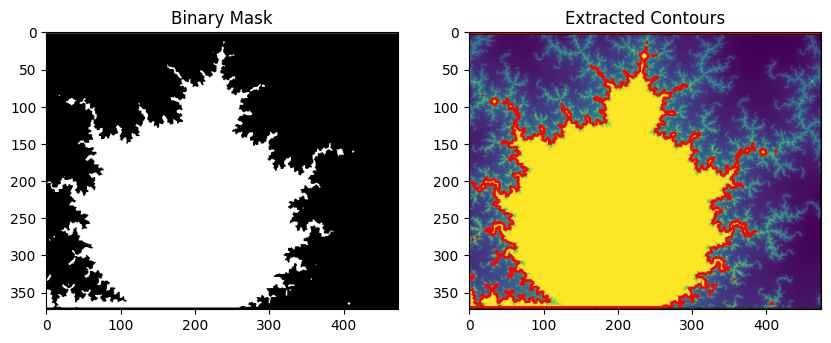

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.interpolate import CubicSpline, PchipInterpolator, splprep, splev
from sympy import Sum, IndexedBase, symbols, Piecewise
import sympy as sym





def lab1_base(filename_in: str, factor: int, filename_out: str):
    points_P = []
    with open(filename_in, 'r') as f:
        for line in f:
            if ',' in line:
                points_P.append(list(map(float, line.strip().split(','))))
    
    P = np.array(points_P)
    
    P_hat = P[::factor]
    
    x_hat = P_hat[:, 0]
    y_hat = P_hat[:, 1]
    
    t = np.zeros(len(P_hat))
    for i in range(1, len(t)):
        t[i] = t[i-1] + np.hypot(x_hat[i] - x_hat[i-1], y_hat[i] - y_hat[i-1])
        
    cs_x = CubicSpline(t, x_hat, bc_type='natural')
    cs_y = CubicSpline(t, y_hat, bc_type='natural')
    
    
    num_segments = len(t) - 1
    coeffs_matrix = []
    
    for j in range(num_segments):
        row = [
            cs_x.c[3, j], cs_x.c[2, j], cs_x.c[1, j], cs_x.c[0, j], # a_j0, a_j1, a_j2, a_j3
            cs_y.c[3, j], cs_y.c[2, j], cs_y.c[1, j], cs_y.c[0, j]  # b_j0, b_j1, b_j2, b_j3
        ]
        coeffs_matrix.append(row)
    
    np.savetxt(filename_out, coeffs_matrix, fmt='%.6e', delimiter='\t')
    print(f"Файл {filename_out} {len(coeffs_matrix)}")







image = cv2.imread('img2.png')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
contours, ret = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = image_rgb.copy()
cv2.drawContours(output, contours, -1, (255, 0, 0), 2) 
main_contour = max(contours, key=cv2.contourArea)




points = np.squeeze(main_contour)
indices = np.linspace(0, len(points) - 1, 100).astype(int)
sampled_points = points[indices]

with open('konturs.txt', 'w') as f:
    for x, y in sampled_points:
        f.write(f"{x},{y}\n")

print(len(sampled_points))



plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(thresh, cmap='gray'), plt.title('Binary Mask')
plt.subplot(122), plt.imshow(output), plt.title('Extracted Contours')
plt.show()





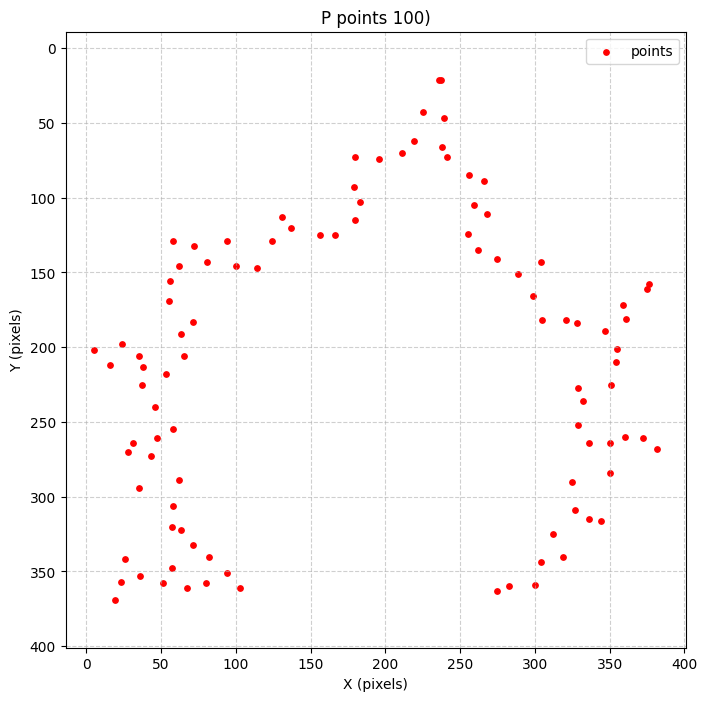

In [2]:


x_coords = []
y_coords = []

try:
    with open('konturs.txt', 'r') as f:
        for line in f:
          
            if ',' in line:
                parts = line.strip().split(',')
                x_coords.append(float(parts[0]))
                y_coords.append(float(parts[1]))
except FileNotFoundError:
    print("error")


x = np.array(x_coords)
y = np.array(y_coords)


plt.figure(figsize=(8, 8))
plt.scatter(x, y, color='red', s=15, label='points')
plt.gca().invert_yaxis()

plt.title(f'P points {len(x)})')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal') 

plt.show()


100
10


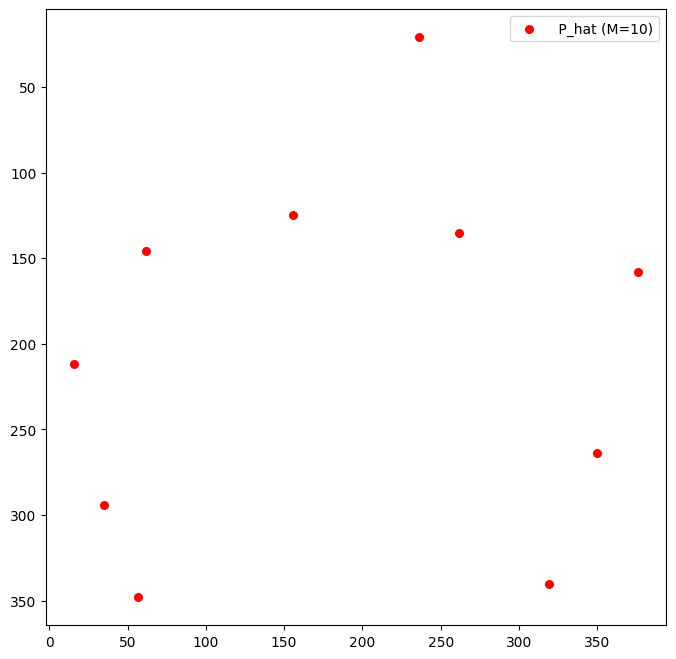

In [9]:
M = 10
points = np.squeeze(main_contour)
indices = np.linspace(0, len(points) - 1, 100).astype(int)
sampled_points2 = points[indices] 

with open('konturs.txt', 'w') as f:
    for px, py in sampled_points2:
        f.write(f"{px},{py}\n")

P_hat = sampled_points2[::M]


not_regular_x = P_hat[:, 0]
not_regular_y = P_hat[:, 1]

print(len(sampled_points2))
print(len(not_regular_x))



indicess = np.linspace(0, len(points) - 1, 100).astype(int)
sampled_points2 = points[indicess] #


with open('coeffs.txt', 'w') as f:
    for x, y in sampled_points2:
        f.write(f"{x},{y}\n")



plt.figure(figsize=(8, 8))
plt.scatter(not_regular_x, not_regular_y, color='red', s=30, label=' P_hat (M=10)')

plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [10]:


# t 
t = np.zeros(len(P_hat))
for i in range(1, len(t)):
    t[i] = t[i-1] + np.hypot(P_hat[i,0] - P_hat[i-1,0], 
                              P_hat[i,1] - P_hat[i-1,1])

# СЛАУ
cs_x = CubicSpline(t, not_regular_x, bc_type='natural')
cs_y = CubicSpline(t, not_regular_y, bc_type='natural')
tau = sym.Symbol('t')
x_segments = []
y_segments = []

for j in range(len(t) - 1):
    t_start, t_end = t[j], t[j+1]
    
    aj0, aj1, aj2, aj3 = cs_x.c[3,j], cs_x.c[2,j], cs_x.c[1,j], cs_x.c[0,j]
    # x_j(t)
    poly_x = aj0 + aj1*(tau - t_start) + aj2*(tau - t_start)**2 + aj3*(tau - t_start)**3
    bj0, bj1, bj2, bj3 = cs_y.c[3,j], cs_y.c[2,j], cs_y.c[1,j], cs_y.c[0,j]
    #  y_j(t)
    poly_y = bj0 + bj1*(tau - t_start) + bj2*(tau - t_start)**2 + bj3*(tau - t_start)**3
   
    condition = (tau >= t_start) & (tau <= t_end)
    x_segments.append((poly_x, condition))
    y_segments.append((poly_y, condition))

x_tilde = sym.Piecewise(*x_segments)
y_tilde = sym.Piecewise(*y_segments)

sym.pprint(x_segments[0][0])


                       3                         2                              
- 7.55625930821406e-6⋅t  - 4.33680868994202e-19⋅t  - 0.479622200599479⋅t + 236.0


Средняя ошибка на 100 точках: 5.58e+01
Станд. отклонение: 3.50e+01


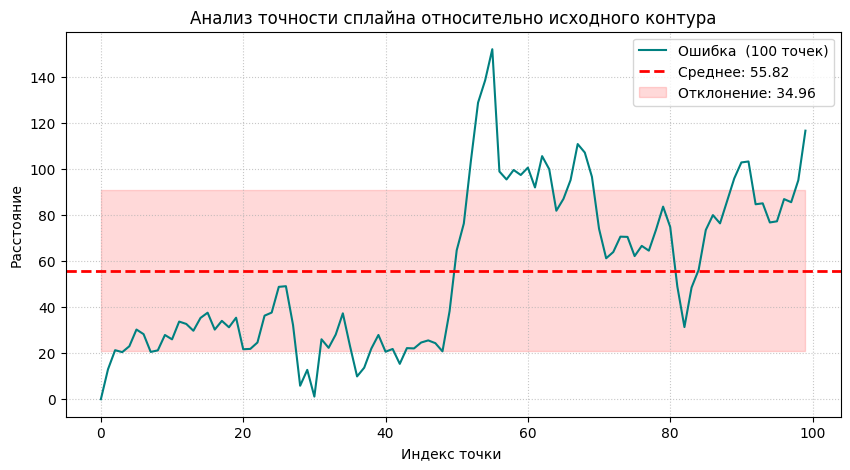

In [11]:

t_100 = np.linspace(0, t[-1], len(sampled_points)) 


x_tilde_100 = cs_x(t_100)
y_tilde_100 = cs_y(t_100)

rho_100 = np.sqrt((x_tilde_100 - sampled_points[:, 0])**2 + 
                   (y_tilde_100 - sampled_points[:, 1])**2)
mean_rho = np.mean(rho_100)
std_rho = np.std(rho_100)

print(f"Средняя ошибка на 100 точках: {mean_rho:.2e}")
print(f"Станд. отклонение: {std_rho:.2e}")

plt.figure(figsize=(10, 5))


plt.plot(range(len(rho_100)), rho_100, color='teal', label='Ошибка  (100 точек)')


plt.axhline(mean_rho, color='red', linestyle='--', linewidth=2, 
            label=f'Среднее: {mean_rho:.2f}')

plt.fill_between(range(len(rho_100)), 
                 max(0, mean_rho - std_rho), 
                 mean_rho + std_rho, 
                 color='red', alpha=0.15, label=f'Отклонение: {std_rho:.2f}')


plt.title("Анализ точности сплайна относительно исходного контура")
plt.xlabel("Индекс точки ")
plt.ylabel("Расстояние")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()


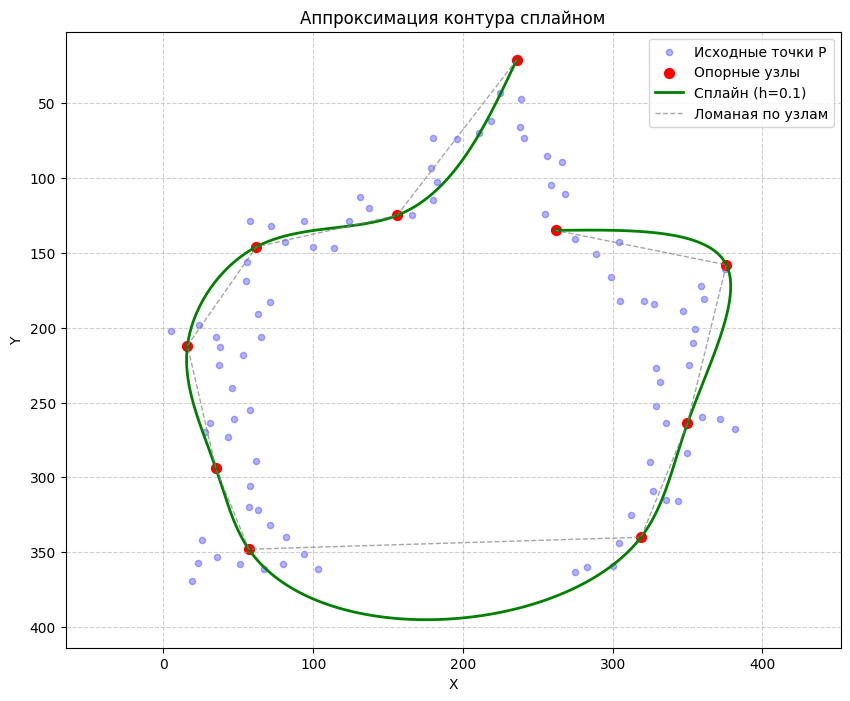

In [12]:

h = 0.1
t_fine = np.arange(0, t[-1] + h, h) 


x_fine = cs_x(t_fine)
y_fine = cs_y(t_fine)

plt.figure(figsize=(10, 8))


plt.scatter(sampled_points2[:, 0], sampled_points2[:, 1], 
            color='blue', s=20, alpha=0.3, label='Исходные точки P')


plt.scatter(not_regular_x, not_regular_y, 
            color='red', s=50, marker='o', label='Опорные узлы ')


plt.plot(x_fine, y_fine, 
         color='green', linewidth=2, label=f'Сплайн (h={h})')


plt.plot(not_regular_x, not_regular_y, 
         color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Ломаная по узлам')


plt.title('Аппроксимация контура сплайном')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().invert_yaxis() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.axis('equal')

plt.show()



In [246]:
class AutoDiffNum:
    def __init__(self, a, b):
        self.a = a
        self.b = b
    def __add__(self, some_else):
     
        return AutoDiffNum(
            self.a + some_else.a,
            self.b + some_else.b)
    def __mul__(self, some_else):
    
        return AutoDiffNum(
            self.a * some_else.a,
            self.a * some_else.b + self.b * some_else.a)
    def __sub__(self, some_else):
     
        return AutoDiffNum(
            self.a - some_else.a,
            self.b - some_else.b)
    def __truediv__(self, some_else):
     
        return AutoDiffNum(
            self.a / some_else.a,
            (self.b * some_else.a - self.a * some_else.b)/(some_else.a ** 2))
    def __repr__(self):
        return f"{self.a} + epsilon{self.b}"
        
    
x = AutoDiffNum(2, 3)
f = x * x / x * x
print("f(x)=", f.a)
print("f'(x)=", f.b)







f(x)= 4.0
f'(x)= 12.0


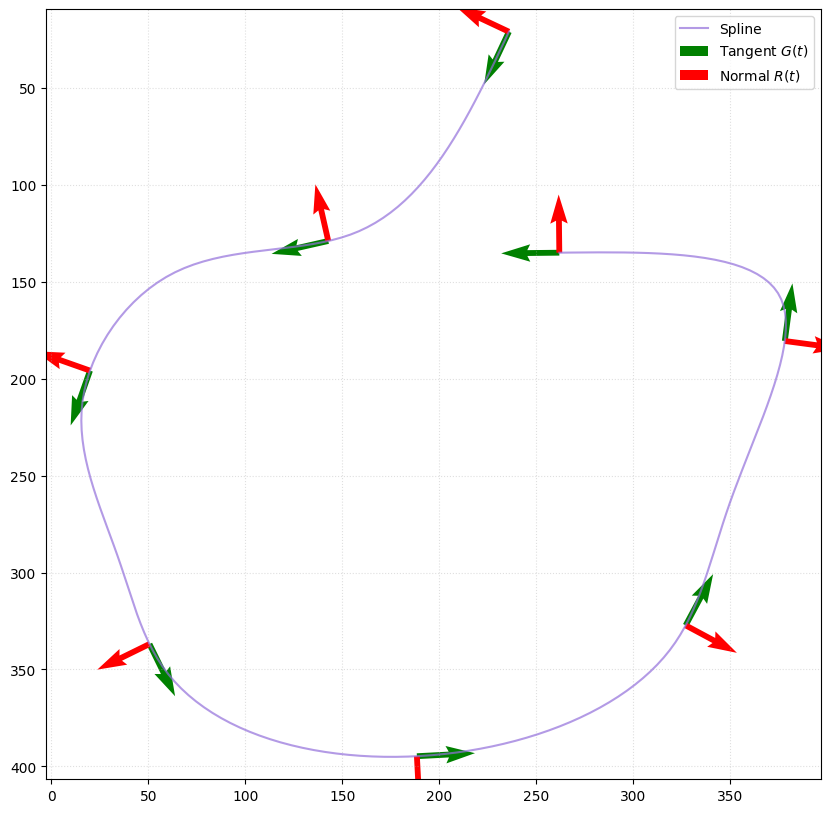

In [303]:

def evaluate_autodiff(cs, t_val):
  
    idx = np.searchsorted(cs.x, t_val) - 1
    idx = max(0, min(idx, len(cs.x) - 2))
    
    dt_val = t_val - cs.x[idx]
    
    dt = AutoDiffNum(dt_val, 1.0)
    # S(t) = c0*dt^3 + c1*dt^2 + c2*dt + c3
    c0 = AutoDiffNum(cs.c[0, idx], 0.0)
    c1 = AutoDiffNum(cs.c[1, idx], 0.0)
    c2 = AutoDiffNum(cs.c[2, idx], 0.0)
    c3 = AutoDiffNum(cs.c[3, idx], 0.0)
    
    # (c0 * dt^3 + c1 * dt^2 + c2 * dt + c3)
    res = ((c0 * dt + c1) * dt + c2) * dt + c3
    return res
def get_G(t_val, cs_x, cs_y):
    res_x = evaluate_autodiff(cs_x, t_val)
    res_y = evaluate_autodiff(cs_y, t_val)
    return np.array([res_x.b, res_y.b]) # (dx/dt, dy/dt)
    
def get_R(G_vec):
    return np.array([-G_vec[1], G_vec[0]])







t_points = np.linspace(0, t[-1], 8)
G_list, R_list, OX, OY = [], [], [], []

for tp in t_points:
    res_x = evaluate_autodiff(cs_x, tp)
    res_y = evaluate_autodiff(cs_y, tp)
    
    # Касательная G = (dx/dt, dy/dt)
    g = np.array([res_x.b, res_y.b])
    # Нормаль R = (-dy, dx)
    r = np.array([-res_y.b, res_x.b])
    g = g / np.linalg.norm(g) * 30  
    r = r / np.linalg.norm(r) * 30
    G_list.append(g)
    R_list.append(r)
    OX.append(res_x.a)
    OY.append(res_y.a)

G_list = np.array(G_list)
R_list = np.array(R_list)

plt.figure(figsize=(10, 10))

# Рисуем сплайн
t_fine = np.linspace(0, t[-1], 200)
plt.plot(cs_x(t_fine), cs_y(t_fine), color='mediumpurple', label='Spline', alpha=0.7)


plt.quiver(OX, OY, G_list[:,0], G_list[:,1], color='green', 
           angles='xy', scale_units='xy', scale=1, label='Tangent $G(t)$')


plt.quiver(OX, OY, R_list[:,0], R_list[:,1], color='red', 
           angles='xy', scale_units='xy', scale=1, label='Normal $R(t)$')

plt.gca().invert_yaxis()
plt.axis('equal')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
